Today we'll try to solve CartPole via a (deep) Q-learning agent. Then, we'll extend it to an actor-critic agent.

# Deep Q-learning

We'll define a network that predicts the Q function values. We'll train it on data from the so-called "replay buffer" - historical list of states, actions and rewards.
The loss will be MSE between the predicted value ($Q(s, a)$, where $s$ is the previous state and $a$ the chosen action) and the Q function Bellman equation estimate ($R + \gamma \cdot \max Q(s', a') $, where state $s'$ was reached from $s$ by doing action $a$ and getting reward $R$)

In [3]:
# loosely based on https://keon.io/deep-q-learning/

import random

import torch
import torch.nn as nn
import numpy as np
import gymnasium as gym


class QNetwork(nn.Module):
    def __init__(self, num_inputs, num_outputs):
        super(QNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(num_inputs, 24),
            nn.ReLU(),
            nn.Linear(24, 24),
            nn.ReLU(),
            nn.Linear(24, num_outputs),
        )

    def forward(self, x):
        return self.net(x)


class DQNAgent:
    def __init__(self, num_inputs, num_outputs, batch_size=32, num_batches=16):
        self.num_inputs = num_inputs
        self.num_outputs = num_outputs
        self.batch_size = batch_size
        self.num_batches = num_batches
        self.eps = 1.0
        self.eps_decay = 0.995
        self.gamma = 0.95
        self.exp_buffer = []
        self.build_model()

    # vytvari model Q-site
    def build_model(self):
        self.model = QNetwork(self.num_inputs, self.num_outputs)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=0.001)
        self.criterion = nn.MSELoss()

    # returns agent's action - epsilon greedy when training and the best one otherwise
    def action(self, state, train=False):
        if train and np.random.uniform() < self.eps:
            return np.random.randint(self.num_outputs)
        else:
            state_tensor = torch.FloatTensor(state)
            with torch.no_grad():
                q_values = self.model(state_tensor)
            return int(torch.argmax(q_values).item())

    # save experience to buffer
    def record_experience(self, exp):
        self.exp_buffer.append(exp)
        if len(self.exp_buffer) > 2000:
            self.exp_buffer = self.exp_buffer[-2000:]

    # If you want to use the target network, the following method copies weights from
    # a given Network to the current one.
    def copy_weights_from(self, other):
        self.model.load_state_dict(other.model.state_dict())
        self.eps = other.eps

    # train based on buffer
    def train(self):
        if len(self.exp_buffer) <= self.batch_size:
            return

        for _ in range(self.num_batches):
            batch = random.sample(self.exp_buffer, self.batch_size)
            states = np.array([s for (s, _, _, _, _) in batch])
            next_states = np.array([ns for (_, _, _, ns, _) in batch])
            states = states.reshape((-1, self.num_inputs))
            next_states = next_states.reshape((-1, self.num_inputs))

            states_tensor = torch.FloatTensor(states)
            next_states_tensor = torch.FloatTensor(next_states)

            with torch.no_grad():
                pred = self.model(states_tensor).numpy()
                next_pred = self.model(next_states_tensor).numpy()

            # compute the target values
            for i, (s, a, r, ns, d) in enumerate(batch):
                pred[i][a] = r
                if not d:
                    pred[i][a] = r + self.gamma * np.amax(next_pred[i])

            targets = torch.FloatTensor(pred)
            self.optimizer.zero_grad()
            outputs = self.model(states_tensor)
            loss = self.criterion(outputs, targets)
            loss.backward()
            self.optimizer.step()

        # decrease epsilon for the epsilon-greedy strategy
        if self.eps > 0.01:
            self.eps = self.eps * self.eps_decay


seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

# create agent (4 inputs, 2 actions)
agent = DQNAgent(4, 2)

env = gym.make("CartPole-v1")
print(env.action_space)

# train the network on 1000 runs of the environment
rewards = []
for i in range(1000):
    obs, _ = env.reset()
    obs = np.reshape(obs, shape=(1, -1))
    done = False
    terminated = False
    R = 0
    t = 0
    while not (done or terminated):
        old_state = obs
        action = agent.action(obs, train=True)
        obs, r, done, terminated, _ = env.step(action)

        R += r
        t += 1
        r = r if not (done or terminated) else 10
        obs = np.reshape(obs, shape=(1, -1))

        agent.record_experience((old_state, action, r, obs, done or terminated))
    agent.train()

    rewards.append(R)
    print(i, R)


Discrete(2)
0 22.0
1 12.0
2 11.0
3 36.0
4 21.0
5 21.0
6 28.0
7 11.0
8 9.0
9 18.0
10 12.0
11 10.0
12 25.0
13 17.0
14 17.0
15 23.0
16 14.0
17 16.0
18 9.0
19 13.0
20 15.0
21 25.0
22 25.0
23 21.0
24 14.0
25 32.0
26 35.0
27 15.0
28 46.0
29 15.0
30 16.0
31 10.0
32 12.0
33 21.0
34 99.0
35 13.0
36 15.0
37 41.0
38 10.0
39 37.0
40 11.0
41 23.0
42 20.0
43 20.0
44 34.0
45 35.0
46 12.0
47 12.0
48 31.0
49 19.0
50 21.0
51 18.0
52 17.0
53 10.0
54 12.0
55 38.0
56 24.0
57 19.0
58 52.0
59 25.0
60 53.0
61 41.0
62 30.0
63 29.0
64 40.0
65 68.0
66 23.0
67 72.0
68 42.0
69 60.0
70 33.0
71 11.0
72 9.0
73 23.0
74 42.0
75 33.0
76 33.0
77 83.0
78 87.0
79 37.0
80 20.0
81 31.0
82 23.0
83 57.0
84 97.0
85 26.0
86 54.0
87 91.0
88 51.0
89 49.0
90 36.0
91 42.0
92 30.0
93 19.0
94 27.0
95 12.0
96 31.0
97 28.0
98 24.0
99 43.0
100 21.0
101 12.0
102 33.0
103 45.0
104 51.0
105 28.0
106 47.0
107 35.0
108 28.0
109 17.0
110 68.0
111 17.0
112 45.0
113 29.0
114 44.0
115 32.0
116 33.0
117 33.0
118 11.0
119 58.0
120 55.0
121 17.0
122

Let us test, how well the agent solves the problem.

In [8]:
env = gym.make("CartPole-v1")
print(env.action_space)

obs, _ = env.reset()
obs = np.reshape(obs, shape=(1, -1))
done = False
R = 0
t = 0
while not (done or terminated):
    old_state = obs
    action = agent.action(obs, train=False)
    obs, r, done, terminated, _ = env.step(action)
    obs = np.reshape(obs, shape=(1, -1))
    R += r
    t += 1
        
print(R)

Discrete(2)
334.0


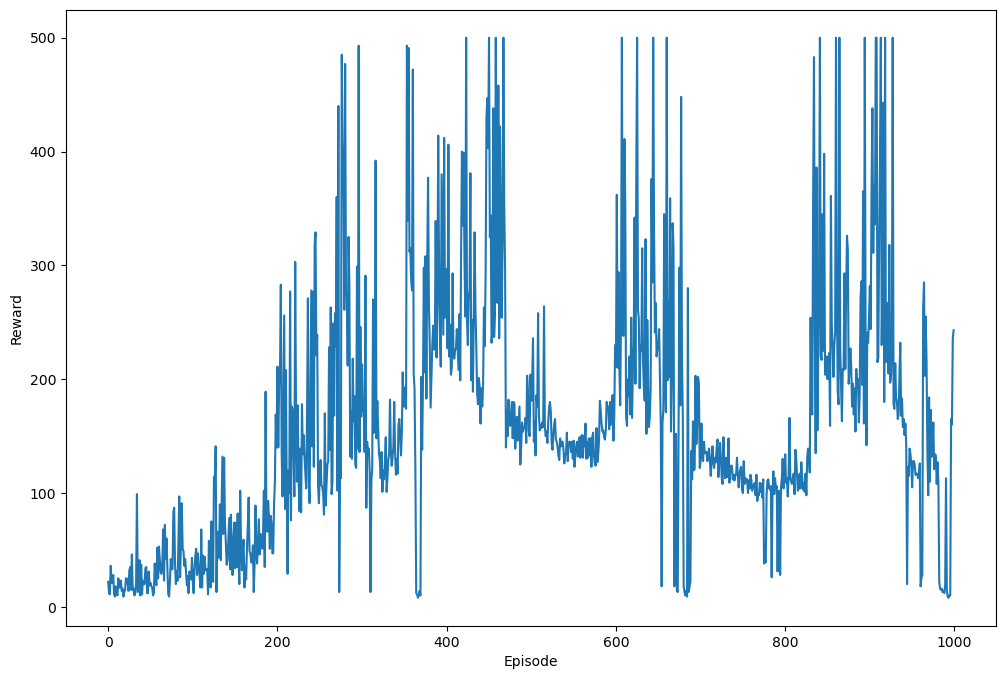

In [9]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(12,8))
plt.plot(rewards)
plt.ylabel('Reward')
plt.xlabel('Episode')
plt.show()

# The Task

Try to solve CartPole or a different env via actor-critic.

Hint: `actor.fit(states, actions, sample_weight=advantages, verbose=False)`